[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sibbirhossain/finguard-xai/blob/main/notebooks/02_solution_and_benchmark.ipynb)

# 02 · The Solution: Temporal Graph AI vs. Conventional Models

**Question:** *does learning from entity relationships detect more fraud than a strong conventional model built on the same information?*

**Method.** Each transaction adds typed, timestamped edges between its card, device, merchant, and IP. A 2-layer temporal GraphSAGE reads the point-in-time neighborhood (2 hops) and outputs a fraud logit and an embedding. The embedding feeds a Deep SVDD novelty detector.

**Baselines on identical data and splits:**
- gradient-boosted trees on the same entity features *without* message passing;
- the anomaly detector alone.

**Split.** Chronological: the model always predicts the future from the past.

In [1]:
# --- Setup: works in Google Colab and inside a local clone ---
import os, sys, subprocess, warnings
warnings.filterwarnings("ignore")
if os.path.exists("../src/models"):
    os.chdir("..")
elif not os.path.exists("src/models"):
    if not os.path.exists("finguard-xai"):
        subprocess.run(["git", "clone", "-q", "https://github.com/sibbirhossain/finguard-xai.git"], check=True)
    os.chdir("finguard-xai")
try:
    import torch_geometric  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch_geometric"], check=True)
sys.path.insert(0, os.getcwd())
import warnings; warnings.filterwarnings("ignore")
import json, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("ready:", os.getcwd())

ready: /home/claude/finguard-xai


In [2]:
from pathlib import Path
from src.models.train import main as train_main
ART = "artifacts/notebook"
if not Path(ART, "model.pt").exists():   # train a compact model (~1-2 min on CPU)
    train_main(["--n-normal", "10000", "--epochs", "4", "--out", ART,
                "--report", "reports/notebook/RESULTS.md", "--bench-n", "100"])
from src.models.pipeline import FinGuardEngine
engine = FinGuardEngine.load(ART)
print("engine loaded · alert threshold", round(engine.scorer.threshold, 3))

# FinGuard-XAI results

**OBSERVED IN THIS IMPLEMENTATION - SYNTHETIC DATA.** Single seed; see README limitations.

- Run: 2026-09-21 06:12:06 · arch=sage · detector=deep_svdd · seed=0 · transactions=10389
- Test fraud rate: 3.14% · chronological split 70/15/15 · thresholds chosen on validation only
- Environment: `{"python": "3.12.3", "torch": "2.14.0+cu130", "platform": "Linux-6.18.44-fc-v37-x86_64-with-glibc2.39", "processor": "x86_64", "torch_threads": 1}`

| Model | PR-AUC | ROC-AUC | Precision | Recall | F1 | FPR | Alerts |
|---|---|---|---|---|---|---|---|
| tabular_gbdt_no_graph | 0.550 | 0.935 | 0.618 | 0.429 | 0.506 | 0.0086 | 34 |
| anomaly_only | 0.302 | 0.920 | 0.290 | 0.633 | 0.397 | 0.0503 | 107 |
| gnn_only | 0.856 | 0.993 | 0.702 | 0.816 | 0.755 | 0.0113 | 57 |
| hybrid_gnn_plus_anomaly | 0.567 | 0.987 | 0.606 | 0.816 | 0.696 | 0.0172 | 66 |

Hybrid recall by scenario: `{"ato": 0.9, "ring": 0.7586206896551724}`

Learned fusion weights: `{"supervised_logit": 0.733325810

In [3]:
report = json.loads(Path("reports/notebook/RESULTS.json").read_text())
import pandas as pd
pd.DataFrame(report["results_test"]).T[["pr_auc", "roc_auc", "precision", "recall", "fpr", "alerts"]].round(3)

,pr_auc,roc_auc,precision,recall,fpr,alerts
tabular_gbdt_no_graph,0.550,0.935,0.618,0.429,0.009,34.0
anomaly_only,0.302,0.920,0.290,0.633,0.050,107.0
gnn_only,0.856,0.993,0.702,0.816,0.011,57.0
hybrid_gnn_plus_anomaly,0.567,0.987,0.606,0.816,0.017,66.0


### Robust results: 5 random seeds (from `reports/EXPERIMENTS.json`)
One run can be lucky. The full suite (`python -m src.experiments.run_experiments`) repeats training on 5 independently generated datasets and reports the mean with a 95% bootstrap confidence interval.

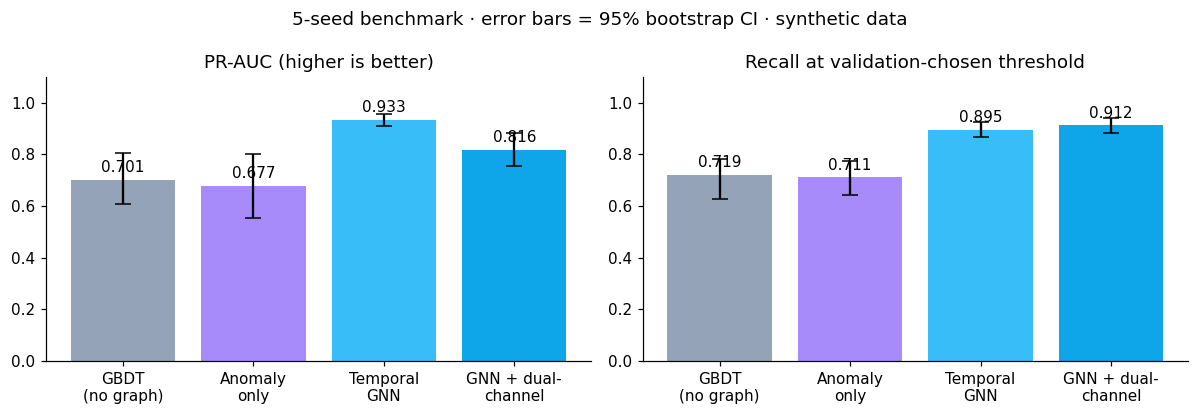

In [4]:
exp = json.loads(Path("reports/EXPERIMENTS.json").read_text())["standard"]
names = {"tabular_gbdt_no_graph": "GBDT\n(no graph)", "anomaly_only": "Anomaly\nonly", "gnn_only": "Temporal\nGNN", "hybrid_gnn_plus_anomaly": "GNN + dual-\nchannel"}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, metric, title in ((axes[0], "pr_auc", "PR-AUC (higher is better)"), (axes[1], "recall", "Recall at validation-chosen threshold")):
    m = [exp[k][metric][0] for k in names]; lo = [exp[k][metric][0] - exp[k][metric][2] for k in names]; hi = [exp[k][metric][3] - exp[k][metric][0] for k in names]
    ax.bar(list(names.values()), m, yerr=[lo, hi], capsize=5, color=["#94a3b8", "#a78bfa", "#38bdf8", "#0ea5e9"])
    for i, v in enumerate(m): ax.text(i, v + 0.03, f"{v:.3f}", ha="center")
    ax.set_ylim(0, 1.1); ax.set_title(title)
fig.suptitle("5-seed benchmark · error bars = 95% bootstrap CI · synthetic data"); plt.tight_layout(); plt.show()

### Reading the result
- On this data, relationship-aware learning is the main driver of performance: the temporal GNN clearly outperforms the non-graph model on PR-AUC, the most informative metric when fraud is rare.
- **The data is synthetic.** It shows the *mechanism* works under controlled, documented conditions. Performance on real bank data would differ. Notebook 07 runs the same pipeline on the public IEEE-CIS benchmark.